In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [3]:
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
FIGURES_DIR = Path("../reports/figures")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

weekly_path = PROCESSED_DIR / "weekly_regional_features.parquet"

weekly_df = pd.read_parquet(weekly_path)

print(weekly_df.shape)
weekly_df.head()

(16006, 35)


,region,week,total_streams,avg_streams_per_track,chart_entries,unique_tracks,unique_artists,avg_rank,best_rank,move_up_count,...,viral_best_rank,viral_move_up_count,viral_move_down_count,viral_new_entry_count,viral_same_position_count,viral_move_up_share,viral_move_down_share,viral_new_entry_share,viral_same_position_share,has_viral50_data
0,Argentina,2016-12-26,7888872.0,39444.360000,200,200,131,100.5,1,65.0,...,1.0,22.0,13.0,9.0,6.0,0.440000,0.260000,0.180000,0.120000,1
1,Argentina,2017-01-02,43192339.0,30851.670714,1400,1400,967,100.5,1,556.0,...,1.0,104.0,142.0,73.0,31.0,0.297143,0.405714,0.208571,0.088571,1
2,Argentina,2017-01-09,43603549.0,31145.392143,1400,1400,974,100.5,1,544.0,...,1.0,124.0,119.0,56.0,51.0,0.354286,0.340000,0.160000,0.145714,1
3,Argentina,2017-01-16,45643782.0,32602.701429,1400,1400,971,100.5,1,532.0,...,1.0,110.0,132.0,60.0,48.0,0.314286,0.377143,0.171429,0.137143,1
4,Argentina,2017-01-23,46698731.0,33356.236429,1400,1400,977,100.5,1,571.0,...,1.0,127.0,134.0,63.0,26.0,0.362857,0.382857,0.180000,0.074286,1


In [4]:
regional_df = weekly_df[weekly_df["region"] != "Global"].copy()

regional_df["week"] = pd.to_datetime(regional_df["week"])

regional_df = regional_df.sort_values(["region", "week"])

print(regional_df.shape)
print(regional_df["region"].nunique())
print(regional_df["week"].min(), regional_df["week"].max())

(15745, 35)
68
2016-12-26 00:00:00 2021-12-27 00:00:00


In [5]:
regional_df["next_week_streams"] = (
    regional_df
    .groupby("region")["total_streams"]
    .shift(-1)
)

regional_df[["region", "week", "total_streams", "next_week_streams"]].head(10)

,region,week,total_streams,next_week_streams
0,Argentina,2016-12-26,7888872.0,43192339.0
1,Argentina,2017-01-02,43192339.0,43603549.0
2,Argentina,2017-01-09,43603549.0,45643782.0
3,Argentina,2017-01-16,45643782.0,46698731.0
4,Argentina,2017-01-23,46698731.0,48097019.0
5,Argentina,2017-01-30,48097019.0,48602348.0
6,Argentina,2017-02-06,48602348.0,48879077.0
7,Argentina,2017-02-13,48879077.0,48900075.0
8,Argentina,2017-02-20,48900075.0,48386865.0
9,Argentina,2017-02-27,48386865.0,47445758.0


In [6]:
regional_df = regional_df.dropna(subset=["next_week_streams"]).copy()

print(regional_df.shape)

(15677, 36)


In [8]:
feature_cols = [
    "total_streams",
    "avg_streams_per_track",
    "chart_entries",
    "unique_tracks",
    "unique_artists",
    "avg_rank",
    "best_rank",
    "move_up_count",
    "move_down_count",
    "new_entry_count",
    "same_position_count",
    "move_up_share",
    "move_down_share",
    "new_entry_share",
    "same_position_share",
    "streams_lag_1_week",
    "weekly_stream_growth",
    "streams_rolling_4_week_avg",
    "streams_vs_4_week_avg",
    "viral_entries",
    "viral_unique_tracks",
    "viral_unique_artists",
    "viral_avg_rank",
    "viral_best_rank",
    "viral_move_up_count",
    "viral_move_down_count",
    "viral_new_entry_count",
    "viral_same_position_count",
    "viral_move_up_share",
    "viral_move_down_share",
    "viral_new_entry_share",
    "viral_same_position_share",
    "has_viral50_data"
]

In [9]:
available_feature_cols = [col for col in feature_cols if col in regional_df.columns]

X = regional_df[available_feature_cols]
y = regional_df["next_week_streams"]

print("Features:", X.shape)
print("Target:", y.shape)
print("Number of features:", len(available_feature_cols))

Features: (15677, 33)
Target: (15677,)
Number of features: 33


In [10]:
unique_weeks = sorted(regional_df["week"].unique())

split_index = int(len(unique_weeks) * 0.8)
split_week = unique_weeks[split_index]

print("Split week:", split_week)

Split week: 2020-12-21 00:00:00


In [11]:
train_df = regional_df[regional_df["week"] < split_week].copy()
test_df = regional_df[regional_df["week"] >= split_week].copy()

X_train = train_df[available_feature_cols]
y_train = train_df["next_week_streams"]

X_test = test_df[available_feature_cols]
y_test = test_df["next_week_streams"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train weeks:", train_df["week"].min(), "to", train_df["week"].max())
print("Test weeks:", test_df["week"].min(), "to", test_df["week"].max())

Train shape: (12344, 33)
Test shape: (3333, 33)
Train weeks: 2016-12-26 00:00:00 to 2020-12-14 00:00:00
Test weeks: 2020-12-21 00:00:00 to 2021-12-20 00:00:00


In [12]:
baseline_pred = X_test["total_streams"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R2:", round(baseline_r2, 3))

Baseline MAE: 2885934.33
Baseline RMSE: 13895208.19
Baseline R2: 0.973


In [13]:
rf_forecaster = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_forecaster.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
rf_pred = rf_forecaster.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest R2:", round(rf_r2, 3))

Random Forest MAE: 3027221.56
Random Forest RMSE: 12812471.51
Random Forest R2: 0.977


In [15]:
forecast_results = pd.DataFrame({
    "model": ["Baseline: current week streams", "Random Forest"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
    "R2": [baseline_r2, rf_r2]
})

forecast_results

,model,MAE,RMSE,R2
0,Baseline: current week streams,2.885934e+06,1.389521e+07,0.972500
1,Random Forest,3.027222e+06,1.281247e+07,0.976619


In [16]:
test_results = test_df[["region", "week", "total_streams", "next_week_streams"]].copy()

test_results["baseline_prediction"] = baseline_pred.values
test_results["rf_prediction"] = rf_pred

test_results["rf_error"] = test_results["next_week_streams"] - test_results["rf_prediction"]
test_results["rf_absolute_error"] = test_results["rf_error"].abs()

test_results.head()

,region,week,total_streams,next_week_streams,baseline_prediction,rf_prediction,rf_error,rf_absolute_error
208,Argentina,2020-12-21,120530478.0,115162467.0,120530478.0,1.187791e+08,-3.616678e+06,3.616678e+06
209,Argentina,2020-12-28,115162467.0,102591841.0,115162467.0,1.127838e+08,-1.019200e+07,1.019200e+07
210,Argentina,2021-01-04,102591841.0,102568978.0,102591841.0,1.015637e+08,1.005307e+06,1.005307e+06
211,Argentina,2021-01-11,102568978.0,111147301.0,102568978.0,1.011107e+08,1.003657e+07,1.003657e+07
212,Argentina,2021-01-18,111147301.0,99759996.0,111147301.0,1.123032e+08,-1.254322e+07,1.254322e+07


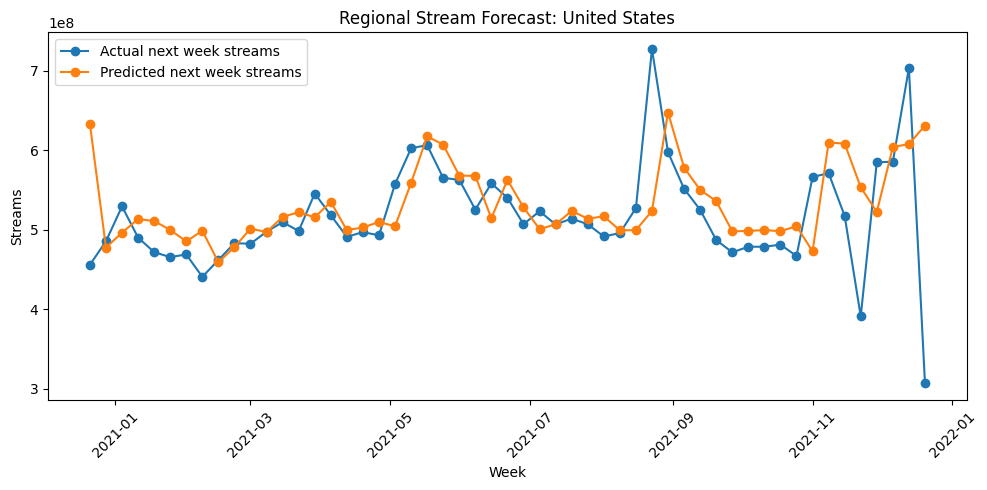

In [17]:
region_to_plot = "United States"

plot_df = test_results[test_results["region"] == region_to_plot].copy()

plt.figure(figsize=(10, 5))
plt.plot(plot_df["week"], plot_df["next_week_streams"], marker="o", label="Actual next week streams")
plt.plot(plot_df["week"], plot_df["rf_prediction"], marker="o", label="Predicted next week streams")
plt.title(f"Regional Stream Forecast: {region_to_plot}")
plt.xlabel("Week")
plt.ylabel("Streams")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"stream_forecast_{region_to_plot.replace(' ', '_')}.png", dpi=300)
plt.show()

In [18]:
forecast_importance = pd.DataFrame({
    "feature": available_feature_cols,
    "importance": rf_forecaster.feature_importances_
}).sort_values("importance", ascending=False)

forecast_importance.head(15)

,feature,importance
1,avg_streams_per_track,0.886273
0,total_streams,0.086831
15,streams_lag_1_week,0.016402
17,streams_rolling_4_week_avg,0.007462
8,move_down_count,0.000321
12,move_down_share,0.000316
18,streams_vs_4_week_avg,0.000288
4,unique_artists,0.000224
16,weekly_stream_growth,0.000175
21,viral_unique_artists,0.000173


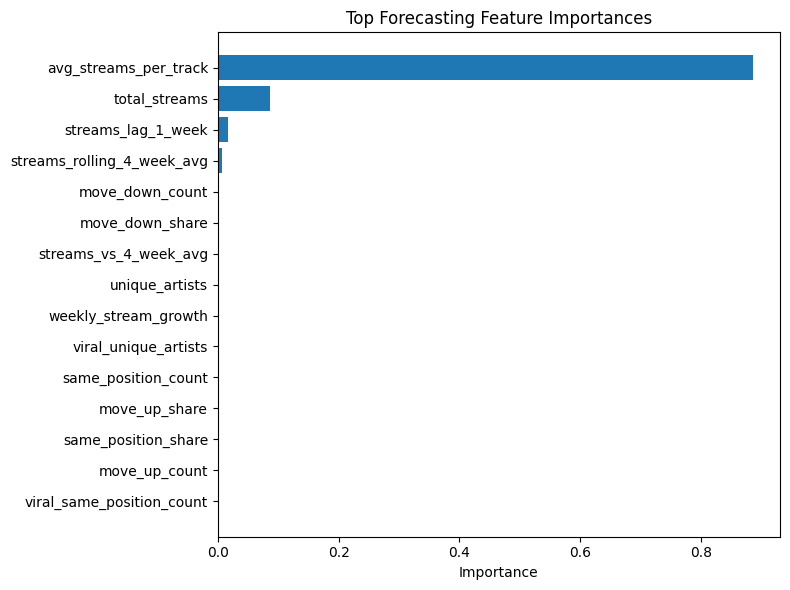

In [19]:
top_forecast_features = forecast_importance.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_forecast_features["feature"], top_forecast_features["importance"])
plt.title("Top Forecasting Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "forecast_feature_importance.png", dpi=300)
plt.show()

In [20]:
forecast_model_path = MODELS_DIR / "regional_stream_forecaster.pkl"

joblib.dump({
    "model": rf_forecaster,
    "feature_cols": available_feature_cols
}, forecast_model_path)

print("Saved regional forecaster to:", forecast_model_path)

Saved regional forecaster to: ../models/regional_stream_forecaster.pkl


In [21]:
forecast_results_path = PROCESSED_DIR / "regional_forecast_test_results.csv"

test_results.to_csv(forecast_results_path, index=False)

print("Saved forecast test results to:", forecast_results_path)

Saved forecast test results to: ../data/processed/regional_forecast_test_results.csv


In [22]:
forecast_results

,model,MAE,RMSE,R2
0,Baseline: current week streams,2.885934e+06,1.389521e+07,0.972500
1,Random Forest,3.027222e+06,1.281247e+07,0.976619


## Forecasting Model vs Baseline Interpretation

The regional stream forecasting model was compared against a simple persistence baseline, where current-week streams were used as the prediction for next-week streams.

The baseline achieved an MAE of approximately 2.89 million streams, an RMSE of approximately 13.90 million streams, and an R2 score of 0.973.

The Random Forest model achieved an MAE of approximately 3.03 million streams, an RMSE of approximately 12.81 million streams, and an R2 score of 0.977.

This means the Random Forest model did not improve average absolute error compared with the baseline. Its MAE was slightly worse than the baseline. However, it achieved a lower RMSE and a slightly higher R2 score, which suggests that it reduced some larger forecasting errors.

This is an important modeling result. Regional stream volume is highly persistent over time, meaning that large markets tend to remain large and smaller markets tend to remain smaller from week to week. Because of this, a simple current-week baseline is already very strong.

The Random Forest model is still useful because it captures additional non-linear signals and reduces large errors, but the baseline remains very competitive. In a portfolio setting, this shows that the model was properly benchmarked against a simple business baseline rather than evaluated in isolation.

The main takeaway is that regional stream volume is highly predictable from recent market-size features such as average streams per track, total streams, lagged streams, and rolling stream averages. For future improvement, the project can focus not only on predicting raw stream volume, but also on predicting regional growth rate, breakout activity, or stream uplift, which are harder and more strategically useful targets.
